In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

In [3]:
df = pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
def make_data_messy(df, seed=42):
    np.random.seed(seed)
    df_messy = df.copy()
    
    # 1. Inject Missing Values (NaNs)
    # We'll hide about 10% of the data in the measurement columns
    for col in df_messy.columns[:-1]:
        df_messy.loc[df_messy.sample(frac=0.1).index, col] = np.nan
        
    # 2. Inject Outliers (The "Fat Finger" Error)
    # Changing a few values to be 100x larger (e.g., 5.1 becomes 510)
    for _ in range(5):
        row = np.random.randint(0, len(df_messy))
        col = np.random.randint(0, 4)
        df_messy.iloc[row, col] *= 100

    # 3. Inject Duplicates
    # Real data often has double-entries
    df_messy = pd.concat([df_messy, df_messy.sample(n=5)], ignore_index=True)

    # 4. Mess with Data Types & Strings
    # Changing 'species' to have inconsistent casing and trailing spaces
    species_map = {
        'setosa': ['setosa', 'Setosa ', 'SETOSA'],
        'versicolor': ['versicolor', 'Versi-color', 'versicolor '],
        'virginica': ['virginica', 'Virginica', 'VIRGINICA']
    }
    df_messy['species'] = df_messy['species'].apply(lambda x: random.choice(species_map[x]))

    # 5. Add a "Garbage" Column
    # Students should learn to drop irrelevant columns
    df_messy['internal_id'] = [f"ID_{np.random.randint(1000, 9999)}" for _ in range(len(df_messy))]

    return df_messy

# --- Usage ---
# from sklearn.datasets import load_iris
# iris = load_iris()
# df = pd.DataFrame(iris.data, columns=iris.feature_names)
# df['species'] = [iris.target_names[i] for i in iris.target]

df_student = make_data_messy(df)

In [4]:
# Shape of the dataset
row = df.shape[0]
col = df.shape[1]

print(f"Number of rows in the dataset is : {row}, and number of columns in the dataset is : {col}")

Number of rows in the dataset is : 150, and number of columns in the dataset is : 6


In [ ]:
# Missing and duplicate values

total_missing = df.isnull().sum().sum()

missing_per_column = df.isnull().sum()

print(f"Total missing values: {total_missing}")
print("-" * 30)
print("Breakdown per column:")
print(missing_per_column)

Total missing values: 0
------------------------------
Breakdown per column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [23]:
# Number of cateforical and numerical features 
numerical_features = len(df.select_dtypes(include=['float64', 'int64']).columns)
categorical_features = len(df.select_dtypes(include=['object']).columns)

print(f"Number of numerical features: {numerical_features}")
print(f"Number of categorical features: {categorical_features}")

Number of numerical features: 5
Number of categorical features: 1


In [24]:
# Removing ID column as it does not have annt significant meaning in the dataset

df = df.drop('Id', axis=1)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# Relation between features

correlation_matrix = df[df.columns[:-1]].corr()     # excluding the 'Species' column, as it would be the target column
correlation_matrix

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


### Pearson Correlation Coefficient Formula

The correlation between two variables $x$ and $y$ is calculated as:

$$r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2 \cdot \sum_{i=1}^{n} (y_i - \bar{y})^2}}$$

**Where:**
* $n$: Total number of observations (rows).
* $x_i, y_i$: Individual data points in the features.
* $\bar{x}, \bar{y}$: The sample means of $x$ and $y$.
* $\sum$: The summation symbol (adding up all values from $1$ to $n$).

<Axes: >

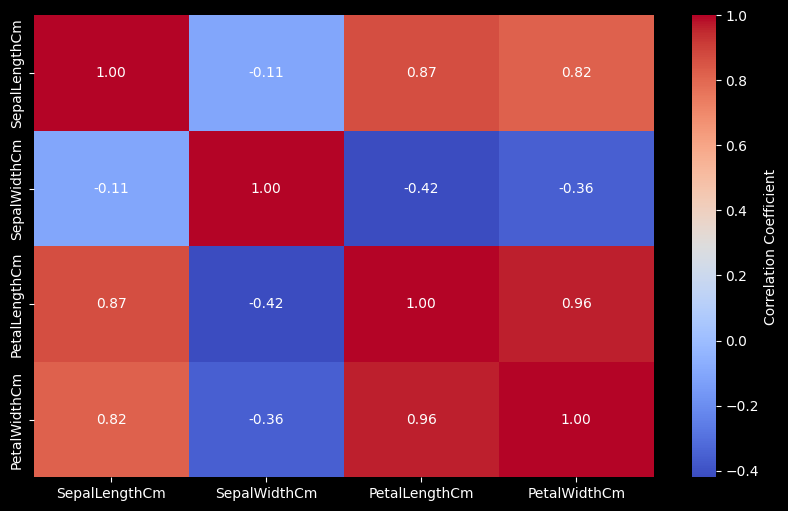

In [22]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6), facecolor='black')
ax.set_facecolor('#282b30')
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            ax=ax,
            cbar_kws={'label': 'Correlation Coefficient'})

### Statistical Observations

#### Strong Positive Growth
* **Sepal Length** is heavily influenced by **Petal Width** and **Petal Length**.
    * *Trend:* As the petal dimensions increase, **Sepal Length** shows a consistent upward trajectory.
* **Petal Synergy:** **Petal Length** and **Petal Width** share the strongest bond in the dataset (**$r = 0.96$**).
    * *Insight:* These two features are almost perfectly collinear; they move nearly in lock-step.

#### The Inverse Outlier: Sepal Width
* While most features grow together, **Sepal Width** exhibits a **negative correlation** with the other three measurements.
    * *Result:* As the overall size of the flower (Length/Petal Width) increases, the **Sepal Width** tends to narrow.

#### Summary of Dependencies
> [!IMPORTANT]
> **Petal Length** relies most heavily on **Petal Width**. Both of these positively influence **Sepal Length**, while **Sepal Width** remains the only feature that moves in the opposite direction of plant scale.

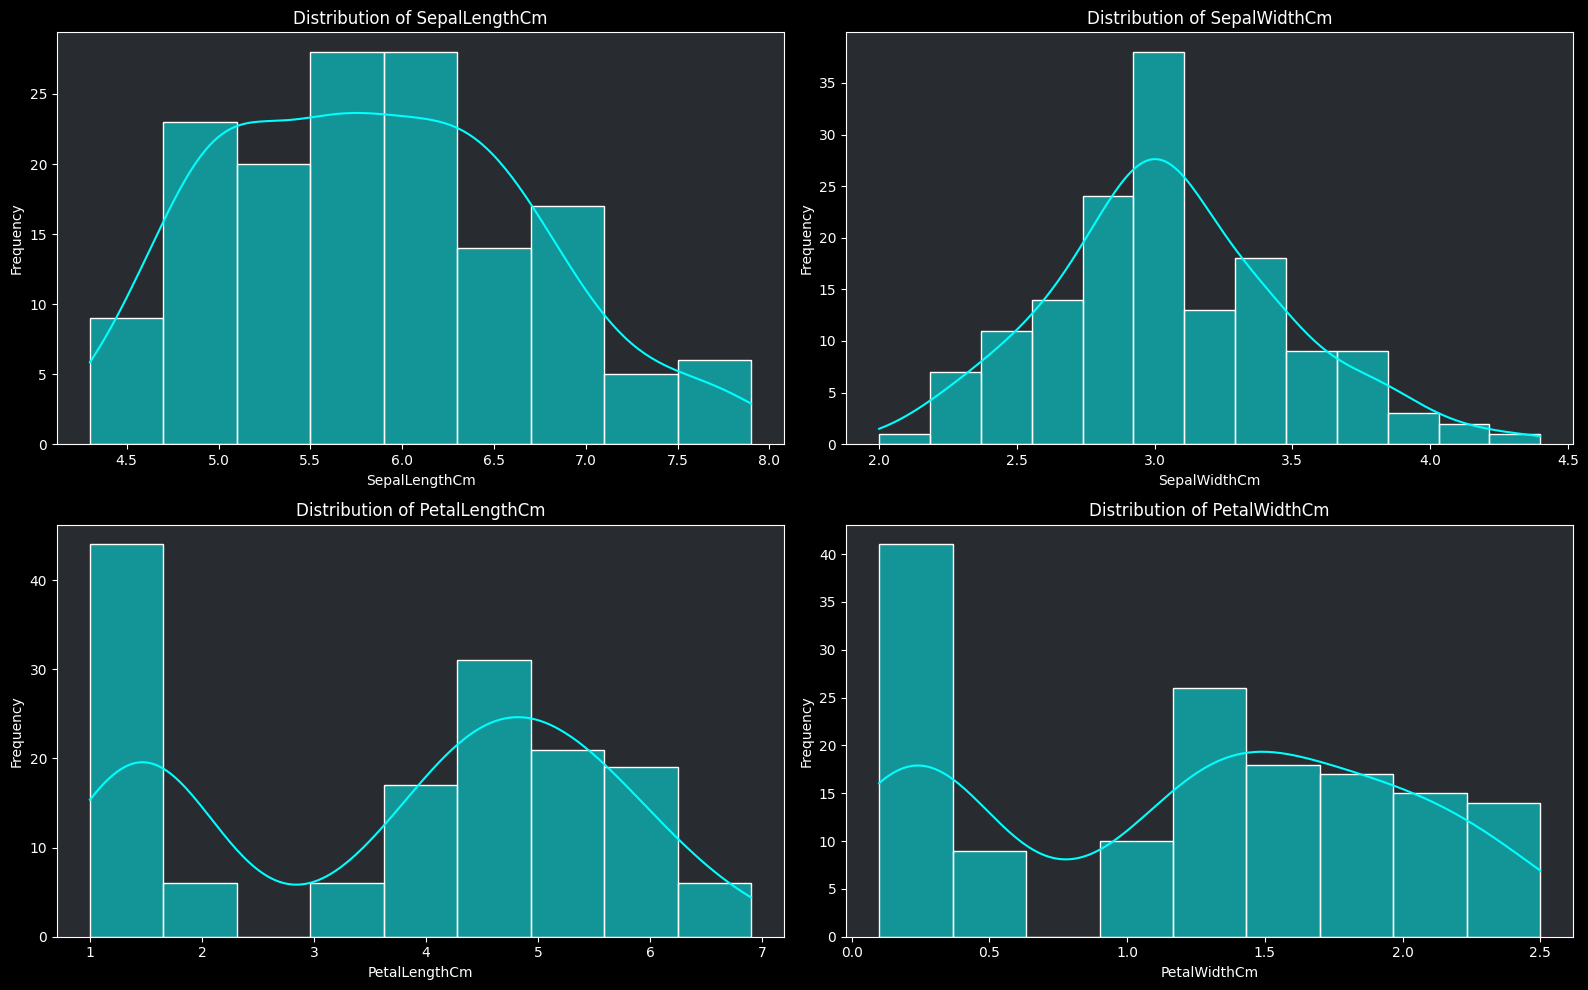

In [30]:
# Plotting the bar plot for each feature 
fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor='black')
for i, col in enumerate(df.columns[:-1]):
    ax = axes.flatten()[i]
    sns.histplot(df[col], ax=ax, kde=True, color='cyan') 
    ax.set_title(f'Distribution of {col}', color='white')
    ax.set_facecolor('#282b30')
    ax.set_xlabel(col, color='white')
    ax.set_ylabel('Frequency', color='white')

plt.tight_layout()
plt.show()

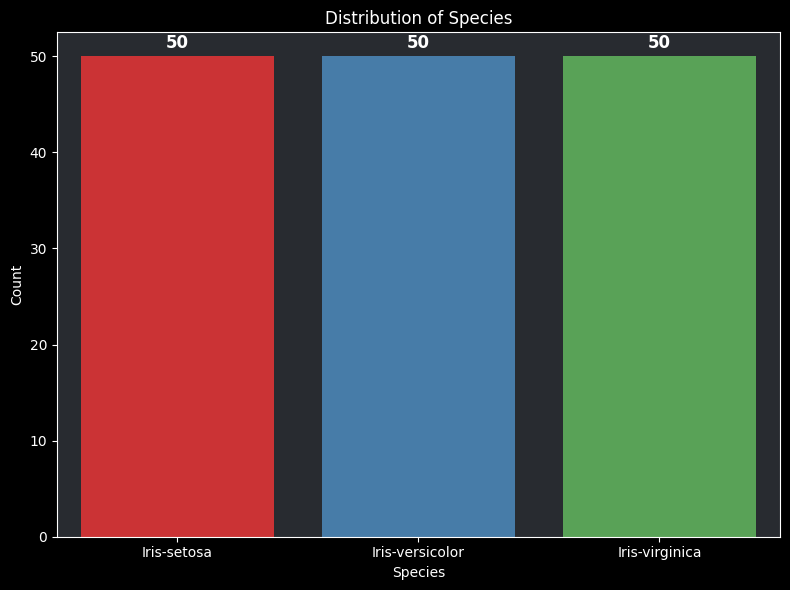

In [43]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6), facecolor='black')
ax = plt.gca()
species_counts = df['Species'].value_counts()
sns.barplot(x=species_counts.index, y=species_counts.values, ax=ax, palette='Set1')
for container in ax.containers:
    ax.bar_label(container, color='white', padding=3, fontsize=12, fontweight='bold')
ax.set_title('Distribution of Species', color='white')
ax.set_facecolor('#282b30')
ax.set_xlabel('Species', color='white')
ax.set_ylabel('Count', color='white')

plt.tight_layout()

### Observation : All the species are of equal size, in this dataset

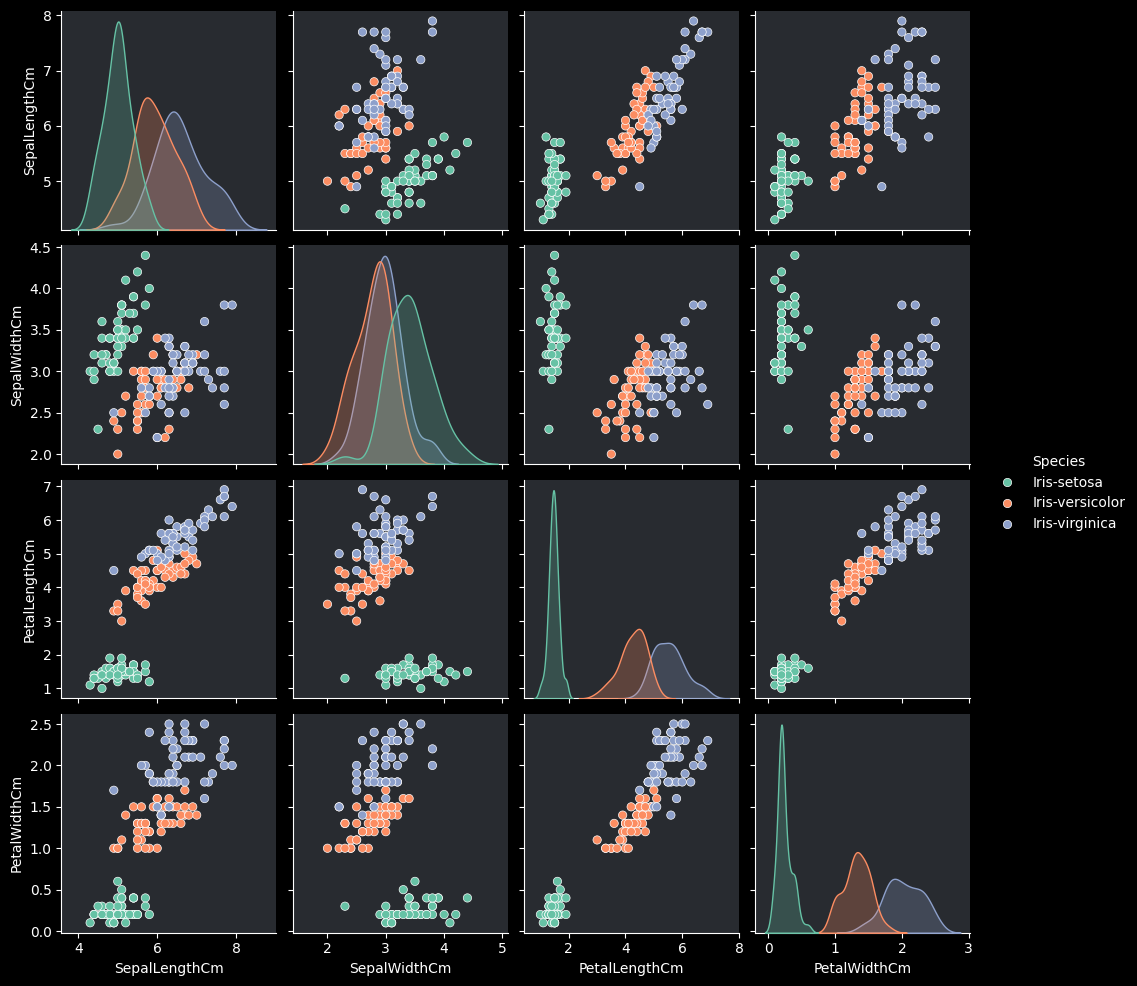

In [46]:
plt.style.use('dark_background')

g = sns.pairplot(df, hue='Species', palette='Set2', diag_kind='kde', height=2.5)

g.fig.set_facecolor('black')
for ax in g.axes.flatten():
    if ax is not None:
        ax.set_facecolor('#282b30')
        ax.tick_params(colors='white')
        ax.xaxis.label.set_color('white')
        ax.yaxis.label.set_color('white')

plt.setp(g._legend.get_texts(), color='white') 

plt.show()

### Multi-Feature Relationship (Pair Plot)

The pair plot provides a birds-eye view of how the numerical features interact with each other and how well they separate the target **Species**.

#### Visual Summary
* **The Diagonal (KDE Plots):** Shows the distribution of each feature. Notice how **Petal Length** and **Petal Width** show distinct "humps" for each species, indicating they are excellent predictors.
* **The Scatter Matrix:** Displays the relationship between pairs of features.
    * *Tight Clusters:* Indicate a strong relationship (e.g., Petal Length vs. Petal Width).
    * *Separation:* If the colors (Set2 palette) don't overlap, the model will have an easy time classifying that species.